# Neural Network from Scratch

I will be implementing this using just numpy and pandas. The problem 

### 1. The Forward Pass Equations
These equations take the input vector x and find the dot product with W1. After you add the bias b1. 

$$Z_{1} = XW_{1} + b_{1}$$

Now we apply an activation function. This allows our neural network to recognize non-linear relationships, as it breaks up the linearity of the forward equation. For this we will use ReLu. 

$$A_{1} = max(0, Z_{1})$$

Following this, we pass this through an output layer to shape the data into the shape we require:

$$Z_{2} = XW_{2} + b_{2}$$

If this is the final layer, then this is equal to y_pred. Else, we put it through more layers.

### 2. Loss Function
The loss function we will use is MSE: $$C=\frac{1}{2}(y_{pred}-y_{true})^{2}$$
This is important as our backward passes will be done to optimize this. 

### 3. Backward Propogation
Now, we need to find the partial derivatives of the MSE equation with respect to the parameters we are optimizing, primarily W and b.

For W2 we get:

$$\frac{\partial C}{\partial W_{2}} = \frac{\partial C}{\partial y_{pred}} * \frac{\partial y_{pred}}{\partial z_{2}} * \frac{\partial z_{2}}{\partial W_{2}}$$

Now we find the individual parts:
$$\frac{\partial C}{\partial y_{pred}} = y_{pred}-y_{true}\\[1em]
\frac{\partial y_{pred}}{\partial z_{2}} = 1 (z_{2} = y_{pred})\\[1em]
\frac{\partial z_{2}}{\partial W_{2}} = A_{1}$$

Hence this gives us:
$$\frac{\partial C}{\partial W_{2}} = (y_{pred} - y_{true}) \cdot A_{1}\\[1em]
\frac{\partial C}{\partial b_{2}} = (y_{pred} - y_{true})$$

For W1:
$$\frac{\partial C}{\partial W_{1}} = \frac{\partial C}{\partial y_{pred}} * \frac{\partial y_{pred}}{\partial Z_{2}} * \frac{\partial Z_{2}}{\partial A_{1}} * \frac{\partial A_{1}}{\partial Z_{1}} * \frac{\partial Z_{1}}{\partial W_{1}}$$

For the rest of the individual parts:
$$\frac{\partial Z_2}{\partial A_1} = W_2$$
$$\frac{\partial A_1}{\partial Z_1} = \mathbf{\frac{\partial \text{ReLU}(Z_1)}{\partial Z_1}}$$
$$\frac{\partial Z_1}{\partial W_1} = x$$

This gives us:
$$\frac{\partial C}{\partial W_{1}} = (y_{pred}-y_{true}) * W_{2} * \mathbf{\frac{\partial \text{ReLU}(Z_1)}{\partial Z_1}} \cdot x\\[1em]\frac{\partial C}{\partial b_{1}} = (y_{pred}-y_{true}) * W_{2} * \mathbf{\frac{\partial \text{ReLU}(Z_1)}{\partial Z_1}}$$

### 4. Gradient Descent
This leaves us with gradient descent, where the real learning happens. 
$$W_{1} = W_{1} - lr * \frac{\partial C}{\partial W_{1}}\\[1em]
b_{1} = b_{1} - lr * \frac{\partial C}{\partial b_{1}} \\[1em]
W_{2} = W_{2} - lr * \frac{\partial C}{\partial W_{2}}\\[1em]
b_{2} = b_{2} - lr * \frac{\partial C}{\partial b_{2}}$$

Alrighty, let's get to coding

In [19]:
def forward_relu(X, W_1, b_1, W_2, b_2):
    Z_1 = np.dot(X, W_1) + b_1
    A_1 = np.maximum(0, Z_1)
    Z_2 = np.dot(A_1, W_2) + b_2
    return {
        "Z_2": Z_2,
        "X": X,
        "Z_1": Z_1,
        "A_1": A_1,
        "W_2": W_2
    }

def forward_tanh(X, W_1, b_1, W_2, b_2):
    Z_1 = np.dot(X, W_1) + b_1
    A_1 = np.tanh(Z_1)
    Z_2 = np.dot(A_1, W_2) + b_2
    return {
        "Z_2": Z_2,
        "X": X,
        "Z_1": Z_1,
        "A_1": A_1,
        "W_2": W_2
    }

def backward_relu(Y_true, cache):
    X = cache["X"]
    Z_1 = cache["Z_1"]
    A_1 = cache["A_1"]
    W_2 = cache["W_2"]
    N = X.shape[0] 
    
    dZ_2 = cache["Z_2"] - Y_true
    dW_2 = np.dot(A_1.T, dZ_2) / N
    db_2 = np.sum(dZ_2, axis=0, keepdims=True) / N
    
    d_relu = (Z_1 > 0).astype(float) 
    dZ_1 = np.dot(dZ_2, W_2.T) * d_relu
    
    dW_1 = np.dot(X.T, dZ_1) / N
    db_1 = np.sum(dZ_1, axis=0, keepdims=True) / N

    return dW_1, db_1, dW_2, db_2

def backward_tanh(Y_true, cache):   
    X = cache["X"]
    Z_1 = cache["Z_1"]
    A_1 = cache["A_1"]
    W_2 = cache["W_2"]
    N = X.shape[0] 
    
    # Layer 2 Gradients
    dZ_2 = cache["Z_2"] - Y_true
    dW_2 = np.dot(A_1.T, dZ_2) / N
    db_2 = np.sum(dZ_2, axis=0, keepdims=True) / N
    
    # Layer 1 Gradients
    # FIX 2: Replaced the ReLU step derivative mask with the true Tanh calculus derivative
    d_tanh = 1 - A_1**2 
    dZ_1 = np.dot(dZ_2, W_2.T) * d_tanh
    
    dW_1 = np.dot(X.T, dZ_1) / N
    db_1 = np.sum(dZ_1, axis=0, keepdims=True) / N

    return dW_1, db_1, dW_2, db_2

def update_parameters(W_1, b_1, W_2, b_2, dW_1, db_1, dW_2, db_2, lr):
    W_1 = W_1 - lr * dW_1
    b_1 = b_1 - lr * db_1
    W_2 = W_2 - lr * dW_2
    b_2 = b_2 - lr * db_2
    
    return W_1, b_1, W_2, b_2


<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_38223/1332789886.py:40: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(X, Y_pred, 'r', linewidth=2, label='NN Prediction ($\hat{Y}$)')


Epoch 0 -> Mean Squared Error: 0.26887
Epoch 1000 -> Mean Squared Error: 0.00504
Epoch 2000 -> Mean Squared Error: 0.00098
Epoch 3000 -> Mean Squared Error: 0.00081
Epoch 4000 -> Mean Squared Error: 0.00077


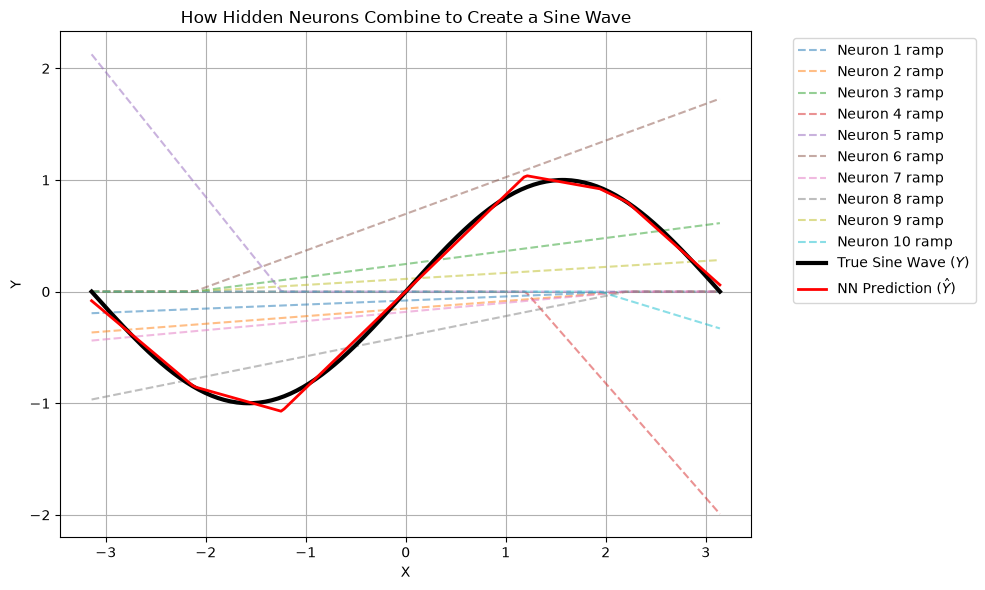

In [20]:
# 1. Generate data
X = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
Y_true = np.sin(X)

# 2. Initialize weights explicitly
H = 10  # 10 hidden neurons
W_1 = np.random.randn(1, H) * 0.1
b_1 = np.zeros((1, H))
W_2 = np.random.randn(H, 1) * 0.1
b_2 = np.zeros((1, 1))

# 3. The Optimization Loop
lr = 0.1
for epoch in range(5000):
    # Step A: Pass data forward to get predictions and track states
    cache = forward_relu(X, W_1, b_1, W_2, b_2)
    
    # Step B: Pass errors backward to derive parameter adjustments
    dW_1, db_1, dW_2, db_2 = backward_relu(Y_true, cache)
    
    # Step C: Subtract the scaled gradients to optimize the system
    W_1, b_1, W_2, b_2 = update_parameters(W_1, b_1, W_2, b_2, dW_1, db_1, dW_2, db_2, lr)
    
    if epoch % 1000 == 0:
        mse = np.mean(0.5 * (cache["Z_2"] - Y_true)**2)
        print(f"Epoch {epoch} -> Mean Squared Error: {mse:.5f}")
plt.figure(figsize=(10, 6))

A_1 = cache["A_1"]
Y_pred = cache["Z_2"]

for i in range(H):
    neuron_output = A_1[:, i] * W_2[i, 0]
    
    if np.max(np.abs(neuron_output)) > 0.01:
        plt.plot(X, neuron_output, '--', alpha=0.5, label=f'Neuron {i+1} ramp')

# Plot the final combined sum vs the True Sine Wave
plt.plot(X, Y_true, 'k', linewidth=3, label='True Sine Wave ($Y$)') # Changed Y to Y_true
plt.plot(X, Y_pred, 'r', linewidth=2, label='NN Prediction ($\hat{Y}$)')

plt.title('How Hidden Neurons Combine to Create a Sine Wave')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend so it doesn't block the line
plt.grid(True)
plt.tight_layout()
plt.show()


Neat right? Let's see what happens when we use tanh instead

<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_38223/74361789.py:40: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(X, Y_pred, 'r', linewidth=2, label='NN Prediction ($\hat{Y}$)')


Epoch 0 -> Mean Squared Error: 0.21239
Epoch 1000 -> Mean Squared Error: 0.00769
Epoch 2000 -> Mean Squared Error: 0.00466
Epoch 3000 -> Mean Squared Error: 0.00341
Epoch 4000 -> Mean Squared Error: 0.00271


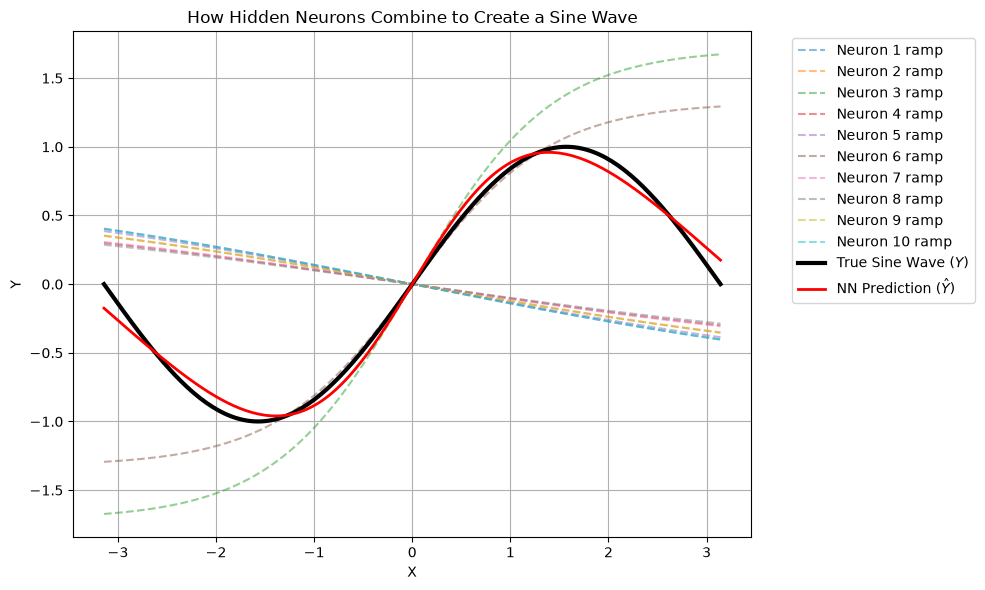

In [21]:
# 1. Generate data
X = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
Y_true = np.sin(X)

# 2. Initialize weights explicitly
H = 10  # 10 hidden neurons
W_1 = np.random.randn(1, H) * 0.1
b_1 = np.zeros((1, H))
W_2 = np.random.randn(H, 1) * 0.1
b_2 = np.zeros((1, 1))

# 3. The Optimization Loop
lr = 0.1
for epoch in range(5000):
    # Step A: Pass data forward to get predictions and track states
    cache = forward_tanh(X, W_1, b_1, W_2, b_2)
    
    # Step B: Pass errors backward to derive parameter adjustments
    dW_1, db_1, dW_2, db_2 = backward_tanh(Y_true, cache)
    
    # Step C: Subtract the scaled gradients to optimize the system
    W_1, b_1, W_2, b_2 = update_parameters(W_1, b_1, W_2, b_2, dW_1, db_1, dW_2, db_2, lr)
    
    if epoch % 1000 == 0:
        mse = np.mean(0.5 * (cache["Z_2"] - Y_true)**2)
        print(f"Epoch {epoch} -> Mean Squared Error: {mse:.5f}")
plt.figure(figsize=(10, 6))

A_1 = cache["A_1"]
Y_pred = cache["Z_2"]

for i in range(H):
    neuron_output = A_1[:, i] * W_2[i, 0]
    
    if np.max(np.abs(neuron_output)) > 0.01:
        plt.plot(X, neuron_output, '--', alpha=0.5, label=f'Neuron {i+1} ramp')

# Plot the final combined sum vs the True Sine Wave
plt.plot(X, Y_true, 'k', linewidth=3, label='True Sine Wave ($Y$)') # Changed Y to Y_true
plt.plot(X, Y_pred, 'r', linewidth=2, label='NN Prediction ($\hat{Y}$)')

plt.title('How Hidden Neurons Combine to Create a Sine Wave')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend so it doesn't block the line
plt.grid(True)
plt.tight_layout()
plt.show()


We can see that tanh allows us to have a much smoother curve. So the activation function we choose will effect the sort of predictions we are able to fit. This seems like a right tool for the right job sort of deal. But what if we were to do away with them altogether...

# Kolmogorov-Arnold Networks
So the idea of this one is that instead of choosing an activation function, we make the activation functions themselves learnable. To do this, we make use of a concept called b-splines. So how do b-splines work? I like to think of them as points that pull the curve towards itself, rather than the curve going through the points. We start with the base case:

$$\begin{equation*}
B_{i, 0}(x) = 
\begin{cases}
    1 & \text{if } t_{i} \leq x < t{i+1}\\
    0  & \text{otherwise}
\end{cases}
\end{equation*}$$

From here, the rest of the basis steps can be defined recursively:

$$\begin{equation*}
B_{i, k}=
\frac{x-t_{i}}{t_{i+k}-t_{i}}B_{i, k-1}+\frac{t_{i+k+1}-x}{t_{i+k+1}-t_{i+1}}B_{i+1, k-1}
\end{equation*}$$

You might be asking, what is t? t is a series of non-decreasing values known as knots. B-splines can be thought of as different polynomials being spliced together, and knots would tell you where one polynomial ends and another begins. 

In [42]:
def bspline_basis(i, k, x, knots):
    if k == 0:
        return 1.0 if knots[i] <= x < knots[i + 1] else 0.0

    # recursive steps
    denom_1 = knots[i + k] - knots[i]
    denom_2 = knots[i + k + 1] - knots[i + 1]

    term_1 = 0.0
    term_2 = 0.0

    if denom_1 > 0:
        term_1 = ((x - knots[i])/denom_1) * bspline_basis(i, k - 1, x, knots)
    
    if denom_2 > 0:
        term_2 = ((knots[i + k + 1] - x)/denom_2) * bspline_basis(i + 1, k - 1, x, knots)
    
    return term_1 + term_2

def bspline_curve(control_points, degree, num_samples = 1000):
    n = len(control_points) - 1
    k = degree

    knots = np.zeros(n + k + 2)
    knots[k+1 : n+1] = np.linspace(1, n - k, n - k)
    knots[n+1:] = n - k + 1

    knots = knots / knots[-1]

    t_values = np.linspace(0.0, 1.0, num_samples)
    t_values[-1] -= 1e-9  # Tiny nudge to avoid out-of-bounds on the final knot
    
    curve = []
    for t in t_values:
        point = np.zeros(2)  # Assuming 2D points (x, y)
        for i in range(len(control_points)):
            N_ip = bspline_basis(i, k, t, knots)
            point += N_ip * np.array(control_points[i])
        curve.append(point)
        
    return np.array(curve)


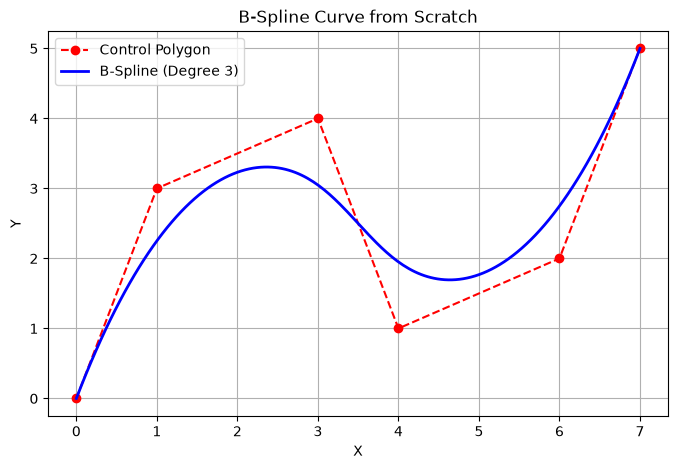

In [43]:
# Define control points (Nx2 array)
control_pts = [
    [0.0, 0.0],
    [1.0, 3.0],
    [3.0, 4.0],
    [4.0, 1.0],
    [6.0, 2.0],
    [7.0, 5.0]
]

degree = 3
curve_points = bspline_curve(control_pts, degree, num_samples=150)

# Plotting
control_pts = np.array(control_pts)
plt.figure(figsize=(8, 5))
plt.plot(control_pts[:, 0], control_pts[:, 1], 'ro--', label='Control Polygon')
plt.plot(curve_points[:, 0], curve_points[:, 1], 'b-', linewidth=2, label=f'B-Spline (Degree {degree})')
plt.title('B-Spline Curve from Scratch')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


Ok now we can get to the math of the KAN. A single KAN layer can be represented by the following summation:

$$y = \sum^{D_{in}}_{i = 1}\phi_i(x_i)$$

Where phi is a customizable, learnable function. To be able to learn this function, we need to parameterize it as follows:

$$\phi(x) = w*\text{SiLu}(x) + S(x)$$

The SiLu bit is still a normal activation function to act as a baseline. S however, is our spline. We know that a B-spline is a weighted sum of its basis functions:

$S = \sum^{M}_{m=1}c_{m}B_{m}$ 

Also can be represented as such:

$S = CB\\[1em] C = \begin{pmatrix} c_{1} & c_{2} & ... & c_{m}\end{pmatrix}^{T}\\[1em]B = \begin{pmatrix} b_{1} & b_{2} & ... & b_{m}\end{pmatrix}$

Where:
$$B = \begin{pmatrix}B_{0,p}(x_{1}) & B_{1, p}(x_{1}) & ... & B_{M-1, p}(x_{1})\\

B_{0,p}(x_{2}) & B_{1, p}(x_{2}) & ... & B_{M-1, p}(x_{2})\\

\vdots & \vdots & \ddots & \vdots\\

B_{0,p}(x_{N}) & B_{1, p}(x_{N}) & ... & B_{M-1, p}(x_{N})\end{pmatrix} $$



Putting all this together we get (equals y_pred as we are only doing 1 pass):
$$y_{pred} = \phi(x) = w*\text{SiLu}(x) + BC$$



### Loss Function

To evaluate the performance of the KAN model, we can optimize once again for the MSE:

$$C_{loss} = \frac{1}{2N}\sum^{N}_{i=1}(y_{actual}-y_{pred})^{2}\\[1em]
=\frac{1}{2N}\sum^{N}_{i=1}(y_{actual}-(w*\text{SiLu}(x) + BC))^{2}$$

Once again, we differentiate with respect to the vectors we are optimizing. In this case, this would be C and w. 

$$\frac{\partial C_{loss}}{\partial C} = \frac{\partial C_{loss}}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial C}$$

Evaluating these seperately:
$$\frac{\partial C_{loss}}{\partial y_{pred}} = \frac{1}{N}(y_{pred} - y_{true})\\[1em]
\frac{\partial y_{pred}}{\partial C} = B$$

Putting these together we get:
$$\frac{\partial C_{loss}}{\partial C} = B^{T} \cdot \frac{1}{N}(y_{pred} - y_{true})$$

Now we move on to optimizing the weights:
$$\frac{\partial C_{loss}}{\partial w} = \frac{\partial C_{loss}}{\partial y_{pred}} \cdot \frac{\partial y_{pred}}{\partial w}$$

Evaluating the individual PDEs:
$$ \frac{\partial y_{pred}}{\partial w} = \text{SiLu}(X)$$

Putting these together we get 
$$\frac{\partial C_{loss}}{\partial w} = \text{SiLu}(X)^{T} \cdot \frac{1}{N}(y_{pred} - y_{true})$$


### 4. Gradient Descent
Now we define the back-proposition:

$$C = C - lr \cdot \frac{\partial C_{loss}}{\partial C}\\[1em]
w = w - lr \cdot \frac{\partial C_{loss}}{\partial w}$$

Alright, and thats it! Now lets write this out in code. 

In [52]:
def silu(x):
    return x / (1 + np.exp(-x))

def bspline_basis(X, T, i, p):
    """
    Evaluates the i-th B-spline basis function of degree p at points X.
    """
    # Base case: Degree 0
    if p == 0:
        # Evaluates the boundary condition element-wise across the entire array X.
        # Returns an array of 1.0s where True, and 0.0s where False.
        return ((X >= T[i]) & (X < T[i+1])).astype(float)
    
    # Recursive steps
    denom1 = T[i+p] - T[i]
    denom2 = T[i+p+1] - T[i+1]
    
    term1 = 0.0
    term2 = 0.0
    
    if denom1 > 0:
        term1 = ((X - T[i]) / denom1) * bspline_basis(X, T, i, p-1)
    if denom2 > 0:
        term2 = ((T[i+p+1] - X) / denom2) * bspline_basis(X, T, i+1, p-1)
        
    return term1 + term2
    
def generate_basis_matrix(X, M, p):
    X_min, X_max = np.min(X), np.max(X)

    interior_knots = np.linspace(X_min, X_max, M - p + 1)

    T = np.concatenate(
        [
            np.full(p, X_min),
            interior_knots,
            np.full(p, X_max + 1e-5)
        ]
    )

    basis_cols = []

    for i in range(M):
        col = bspline_basis(X, T, i, p)
        basis_cols.append(col)
    
    return np.hstack(basis_cols)

def forward_KAN(X, w, C, M, p):
    B = generate_basis_matrix(X, M, p)

    Y_pred = w * silu(X) + np.dot(B, C)
    
    cache = {
        "X": X,
        "B": B,
        "Y_pred": Y_pred
    }
    return Y_pred, cache

def backward_KAN(Y_true, cache):
    X = cache["X"]
    B = cache["B"]
    Y_pred = cache["Y_pred"]
    N = len(Y_true)

    dC = 1/N * np.dot(B.T, (Y_pred - Y_true))
    dw = 1/N * np.dot(silu(X).T, (Y_pred - Y_true))

    return dC, dw

def update_parameters(C, w, dC, dw, lr):
    C = C - lr * dC
    w = w - lr * dw

    return C, w



<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_38223/3277297123.py:38: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(X, Y_pred, 'r', linewidth=2, label='KAN Final Prediction ($\hat{Y}$)')


Epoch  500 | Cost (MSE): 0.000239
Epoch 1000 | Cost (MSE): 0.000049
Epoch 1500 | Cost (MSE): 0.000026
Epoch 2000 | Cost (MSE): 0.000015


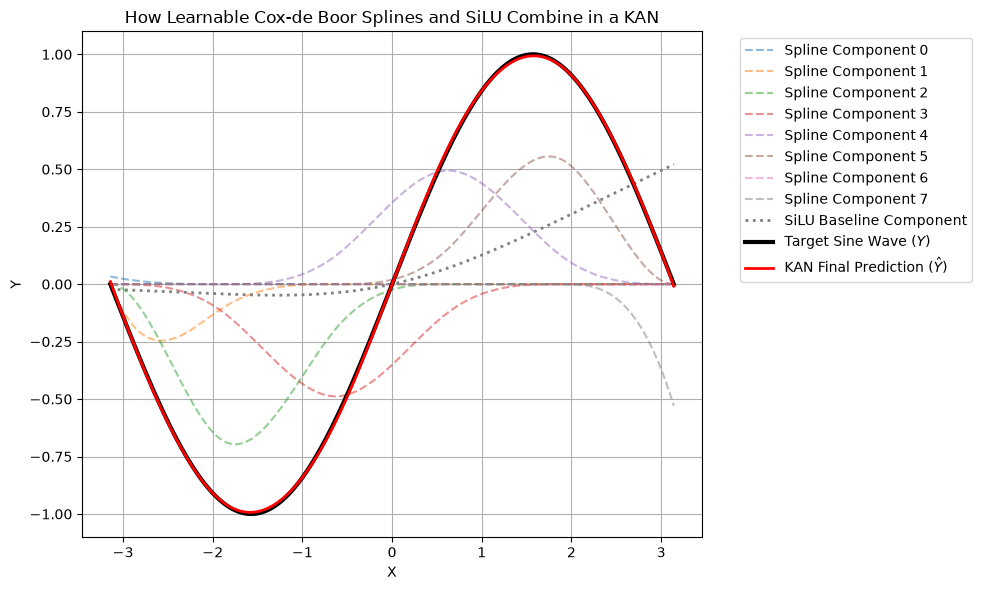

In [62]:
X = np.linspace(-np.pi, np.pi, 200).reshape(-1, 1)
Y_true = np.sin(X)

M = 8
p = 3

np.random.seed(42)
C = np.random.randn(M, 1) * 0.1 
w = np.random.randn(1, 1) * 0.1

lr = 0.1
epochs = 2000

for epoch in range(epochs):
    Y_pred, cache = forward_KAN(X, w, C, M, p)

    dC, dw = backward_KAN(Y_true, cache)

    C, w = update_parameters(C, w, dC, dw, lr)
    if (epoch + 1)% 500 == 0:
        mse = np.mean(0.5 * (Y_pred - Y_true) ** 2)
        print(f"Epoch {epoch + 1:4d} | Cost (MSE): {mse:.6f}")


plt.figure(figsize=(10, 6))

# Plot what each individual spline basis function contributed to the system
B = cache["B"]
for m in range(M):
    individual_spline_contribution = B[:, m:m+1] * C[m, 0]
    plt.plot(X, individual_spline_contribution, '--', alpha=0.5, label=f'Spline Component {m}')

# Plot global baseline contribution
plt.plot(X, w * silu(X), ':', color='gray', linewidth=2, label='SiLU Baseline Component')

# Plot overall target vs learned fit
plt.plot(X, Y_true, 'k', linewidth=3, label='Target Sine Wave ($Y$)')
plt.plot(X, Y_pred, 'r', linewidth=2, label='KAN Final Prediction ($\hat{Y}$)')

plt.title('How Learnable Cox-de Boor Splines and SiLU Combine in a KAN')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
